In [1]:
import numpy as np
import pandas as pd
import ast
import math
import plotly.express as px
import matplotlib.pyplot as plt

In [2]:
def calc_alliance_area(teams, comp):
    scoring_cols = list(comp.columns)[2:]
    scoring_cols = [col for col in scoring_cols if 'L1' not in col]
    robots = comp[comp['Team Number'].isin(teams)]
    area = 0
    for i, col in enumerate(scoring_cols):
        a_col = col
        if i == len(scoring_cols)-1:
            b_col = scoring_cols[0]
        else:
            b_col = scoring_cols[i+1]
        a = np.mean(robots[a_col].values)
        b = np.mean(robots[b_col].values)
        c = math.radians(360/len(scoring_cols))
        triangle = 0.5*a*b*math.sin(c)
        area+= triangle
    return area

In [3]:
# Sample DataFrame (replace this with your actual data)

def show_alliance_radar(teams, combined = False):
    scoring_cols = list(comp.columns)[2:]
    robots = comp[comp['Team Number'].isin(teams)]
    robots_team_nums = list(robots['Team Number'].values)
    alliance_data = robots[scoring_cols]
    if combined:
        total_teams = alliance_data.sum()/len(teams)
        alliance_data = alliance_data.append(total_teams, ignore_index=True)
        robots_team_nums.append('Full Alliance')
    
    # Number of variables
    num_vars = len(alliance_data.columns)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # Complete the circle
    angles += angles[:1]

    # Plot radar chart for each row
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

    # Loop through rows in the DataFrame to plot each radar chart
    for i, row in alliance_data.iterrows():
        values = row.tolist()
        values += values[:1]  # Complete the loop
        ax.plot(angles, values, linewidth=1, linestyle='solid', label=f'{robots_team_nums[i]}')
        ax.fill(angles, values, alpha=0.25)

    # Add labels for each axis
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(alliance_data.columns)

    # Add a title and legend
    teams_string = ''
    for team in teams:
        teams_string = teams_string + ' ' + str(team)
    plt.title('Radar Plot of ' + teams_string)
    
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

    # Show the plot
    plt.show()


In [4]:
def optimize(team, top_8, just_outside, comp, picking = True):
    alliances = []
    all_robots = list(comp['Team Number'])
    non_higher_captains = all_robots.copy()
    if picking:
        for captain in top_8:
            if captain != team:
                non_higher_captains.remove(captain)
            else:
                non_higher_captains.remove(captain)
                break
        for captain in just_outside:
            if captain != team:
                non_higher_captains.remove(captain)
            else:
                non_higher_captains.remove(captain)
                break
                
    my_alliance = []
    my_alliance_teams = [team]
    for robot in top_8:
        teams = [robot]
        all_robots.remove(robot)
        best_area = 0
        best_robot = ''
        if robot != team:
            # Output your alliance's current suggested picks
            print('Our Top 5')
            options_dict = {'Teams':[], 'Area': []}
            for robot_add in non_higher_captains:
                my_alliance_teams.append(robot_add)
                area = calc_alliance_area(my_alliance_teams,comp)
                options_dict['Teams'].append(robot_add)
                options_dict['Area'].append(area)
                if area > best_area:
                    best_area = area
                    best_robot = robot_add
                my_alliance_teams.remove(robot_add)
            options_df = pd.DataFrame(options_dict).sort_values(by='Area',ascending = False)
            print('Suggested Picks')
            for option in options_df.head()['Teams']:
                possible_alliance = []
                for our_teams in my_alliance_teams:
                    possible_alliance.append(our_teams)
                possible_alliance.append(option)
                show_alliance_radar(possible_alliance, combined = True)
            print(options_df.head())
            
            # Their Pick
            print("Alliance Drafting: ")
            print(teams)
            print(all_robots)
            best_robot = int(input("Team Selected: "))
            teams.append(best_robot)
            if best_robot == team:
                my_alliance = teams
            all_robots.remove(best_robot)
            if best_robot in non_higher_captains:
                non_higher_captains.remove(best_robot)
        else:
            print("My alliance Drafting: ")
            print(robot)
            options_dict = {'Teams':[], 'Area': []}
            for robot_add in all_robots:
                teams.append(robot_add)
                area = calc_alliance_area(teams,comp)
                options_dict['Teams'].append(robot_add)
                options_dict['Area'].append(area)
                if area > best_area:
                    best_area = area
                    best_robot = robot_add
                teams.remove(robot_add)
            options_df = pd.DataFrame(options_dict).sort_values(by='Area',ascending = False)
            print('Suggested Picks')
            for option in options_df.head()['Teams']:
                show_alliance_radar([team, option], combined = True)
            print(options_df.head())
            best_robot = int(input("Team Selected: "))
            teams.append(best_robot)
            all_robots.remove(best_robot)
            if best_robot in non_higher_captains:
               non_higher_captains.remove(best_robot)
            print(best_robot)
            my_alliance = teams
            my_alliance_teams = teams
        if best_robot in top_8:
            top_8.remove(best_robot)
            top_8.append(just_outside[0])
            just_outside.remove(just_outside[0])
        if best_robot in just_outside:
            just_outside.remove(best_robot)

        alliances.append(teams)

    alliances_r = alliances[::-1]
    for alliance in alliances_r:
        best_area = 0
        best_robot = ''
        if alliance != my_alliance:
            # Output your alliance's current suggested picks
            print('Our Top 5')
            options_dict = {'Teams':[], 'Area': []}
            for robot_add in all_robots:
                my_alliance.append(robot_add)
                area = calc_alliance_area(my_alliance,comp)
                options_dict['Teams'].append(robot_add)
                options_dict['Area'].append(area)
                if area > best_area:
                    best_area = area
                    best_robot = robot_add
                my_alliance.remove(robot_add)
            options_df = pd.DataFrame(options_dict).sort_values(by='Area',ascending = False)
            print('Suggested Picks')
            for option in options_df.head()['Teams']:
                possible_alliance = []
                for our_teams in my_alliance:
                    possible_alliance.append(our_teams)
                possible_alliance.append(option)
                show_alliance_radar(possible_alliance, combined = True)
            print(options_df.head())
            
            # Their Pick
            print("Alliance Drafting: ")
            print(alliance)
            print(all_robots)
            best_robot = int(input("Team Selected: "))
            alliance.append(best_robot)
            all_robots.remove(best_robot)
        else:
            print("My alliance Drafting: ")
            print(alliance)
            options_dict = {'Teams':[], 'Area': []}
            for robot_add in all_robots:
                alliance.append(robot_add)
                area = calc_alliance_area(alliance,comp)
                options_dict['Teams'].append(robot_add)
                options_dict['Area'].append(area)
                if area > best_area:
                    best_area = area
                    best_robot = robot_add
                alliance.remove(robot_add)
            options_df = pd.DataFrame(options_dict).sort_values(by='Area',ascending = False)
            print('Suggested Picks')
            for option in options_df.head()['Teams']:
                possible_alliance = []
                for our_teams in my_alliance:
                    possible_alliance.append(our_teams)
                possible_alliance.append(option)
                show_alliance_radar(possible_alliance, combined = True)
            print(options_df.head())
            best_robot = int(input("Team Selected: "))
            alliance.append(best_robot)
            print(best_robot)
            all_robots.remove(best_robot)

    for alliance in alliances_r:
        best_area = 0
        best_robot = ''
        if alliance != my_alliance:
            print("Alliance Drafting: ")
            print(alliance)
            best_robot = int(input("Team Selected: "))
            alliance.append(best_robot)
            all_robots.remove(best_robot)
        else:
            print("My alliance Drafting: ")
            print(alliance)
            options_dict = {'Teams':[], 'Area': []}
            for robot_add in all_robots:
                alliance.append(robot_add)
                area = calc_alliance_area(alliance,comp)
                options_dict['Teams'].append(robot_add)
                options_dict['Area'].append(area)
                if area > best_area:
                    best_area = area
                    best_robot = robot_add
                alliance.remove(robot_add)
            options_df = pd.DataFrame(options_dict).sort_values(by='Area',ascending = False)
            print('Suggested Picks')
            print(options_df.head())
            best_robot = int(input("Team Selected: "))
            alliance.append(best_robot)
            print(best_robot)
            all_robots.remove(best_robot)
            
    alliances = alliances_r[::-1]

    return alliances

In [5]:
def optimize_all(team, top_8, just_outside, comp, picking = True):
    alliances = []
    all_robots = list(comp['Team Number'])
    non_higher_captains = all_robots.copy()
    if picking:
        for captain in top_8:
            if captain != team:
                non_higher_captains.remove(captain)
            else:
                non_higher_captains.remove(captain)
                break
        for captain in just_outside:
            if captain != team:
                non_higher_captains.remove(captain)
            else:
                non_higher_captains.remove(captain)
                break
    
    for robot in top_8:
        teams = [robot]
        all_robots.remove(robot)
        best_area = 0
        best_robot = ''
        print(robot)
        options_dict = {'Teams':[], 'Area': []}
        for robot_add in all_robots:
            teams.append(robot_add)
            area = calc_alliance_area(teams,comp)
            options_dict['Teams'].append(robot_add)
            options_dict['Area'].append(area)
            if area > best_area:
                best_area = area
                best_robot = robot_add
            teams.remove(robot_add)
        options_df = pd.DataFrame(options_dict).sort_values(by='Area',ascending = False)
        print('Suggested Picks')
        pick = options_df.head()['Teams'].tolist()[0]
        best_robot = pick
        teams.append(best_robot)
        all_robots.remove(best_robot)
        non_higher_captains.remove(best_robot)
        print(best_robot)
        if best_robot in top_8:
            top_8.remove(best_robot)
            top_8.append(just_outside[0])
            just_outside.remove(just_outside[0])
        if best_robot in just_outside:
            just_outside.remove(best_robot)

        alliances.append(teams)

    alliances_r = alliances[::-1]
    for alliance in alliances_r:
        best_area = 0
        best_robot = ''
        print("My alliance Drafting: ")
        print(alliance)
        options_dict = {'Teams':[], 'Area': []}
        for robot_add in all_robots:
            alliance.append(robot_add)
            area = calc_alliance_area(alliance,comp)
            options_dict['Teams'].append(robot_add)
            options_dict['Area'].append(area)
            if area > best_area:
                best_area = area
                best_robot = robot_add
            alliance.remove(robot_add)
        options_df = pd.DataFrame(options_dict).sort_values(by='Area',ascending = False)
        print('Suggested Picks')
        best_robot = options_df.head()['Teams'].tolist()[0]
        alliance.append(best_robot)
        print(best_robot)
        all_robots.remove(best_robot)

    
    alliances = alliances_r[::-1]

    return alliances

In [6]:
# from google.colab import drive
# drive.mount('/content/drive')

In [7]:
comp = pd.read_csv('/mnt/home/ranier-gran/Documents/Robotics/match_scouting_2025_radar.csv')
# column_to_move = comp.pop("Passes")
# comp.insert(6, "Passes", column_to_move)
comp

,Unnamed: 0,Team Number,TeleopAlgaeNorm,L1,L2,L3,L4,AutoNorm,EndgameNorm
0,0,69,0.159091,0.072727,0.151515,0.101010,0.289773,0.122117,0.303030
1,1,78,0.429825,0.933333,0.444444,0.370370,0.250000,0.402985,1.000000
2,2,88,0.221053,0.400000,1.000000,0.666667,0.562500,0.707463,0.733333
3,3,157,0.436288,0.147368,0.070175,0.146199,0.424342,0.247447,0.771930
4,4,190,0.294737,0.480000,1.000000,1.000000,0.787500,0.895522,0.733333
5,5,246,0.122807,0.000000,0.444444,0.370370,0.625000,0.104478,0.111111
6,6,467,0.000000,0.000000,0.222222,0.648148,0.562500,0.701493,0.666667
7,7,1119,0.405263,0.080000,0.333333,0.944444,0.000000,0.161194,0.800000
8,8,1153,1.000000,0.057143,0.095238,0.357143,0.026786,0.402985,0.619048
9,9,1277,0.000000,0.266667,0.000000,0.648148,1.000000,1.000000,0.444444


In [8]:
top_8 = [6328,1768,2423,190,88,1757,9991,1153]
just_outside = [4909,5000,157,467,6731,78,5735]
all_robots = list(comp['Team Number'])

Our Top 5
Suggested Picks


/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


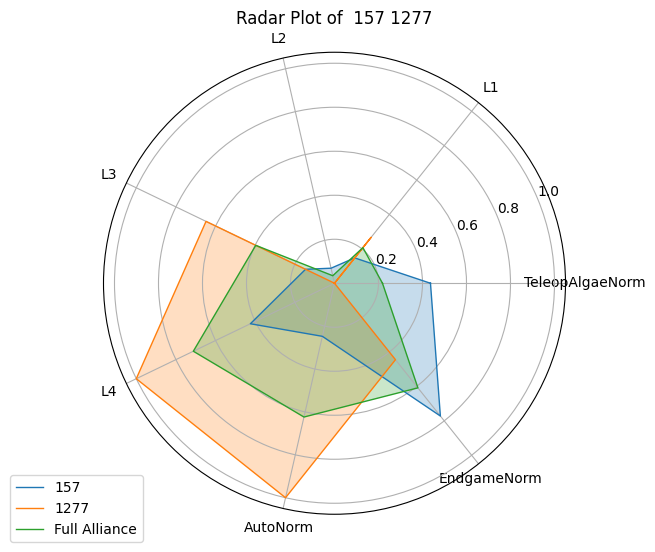

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


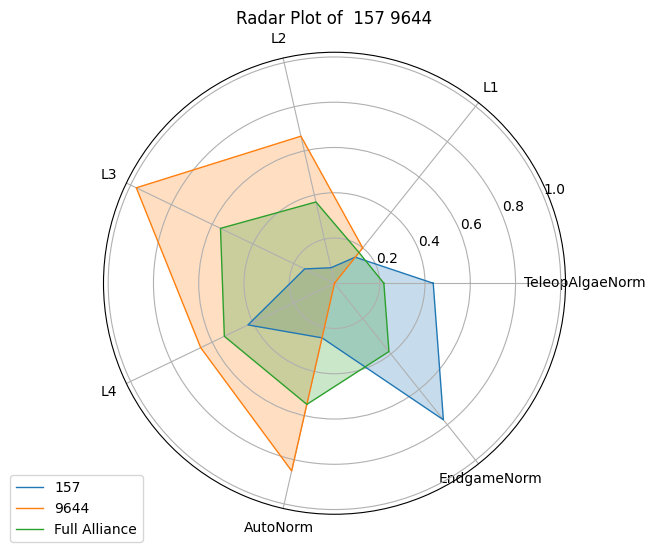

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


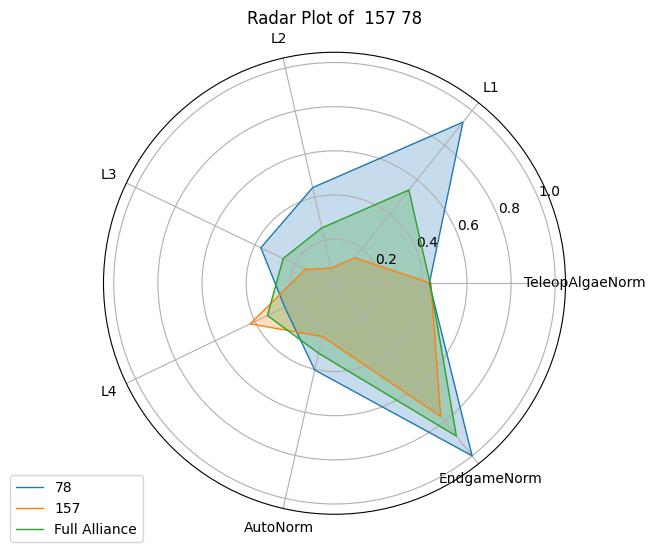

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


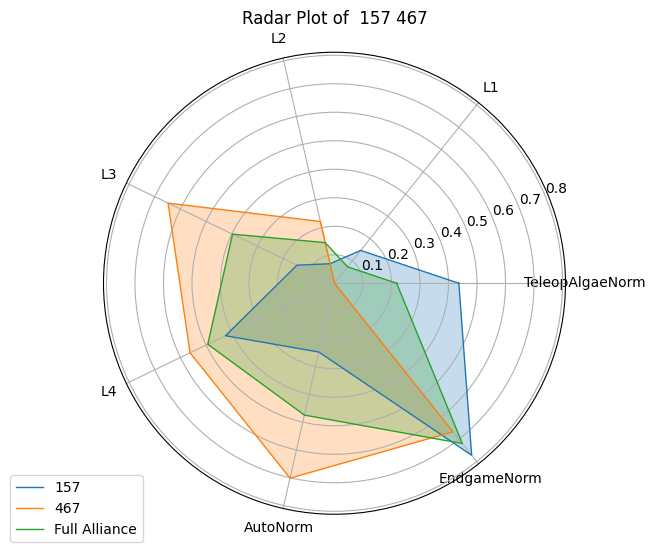

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


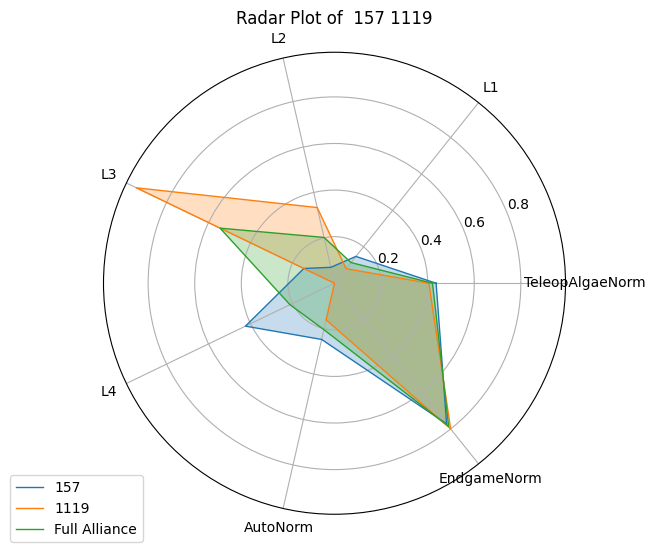

    Teams      Area
5    1277  0.545880
18   9644  0.511533
1      78  0.453118
3     467  0.440912
4    1119  0.366013
Alliance Drafting: 
[6328]
[69, 78, 88, 157, 190, 246, 467, 1119, 1153, 1277, 1757, 1768, 2079, 2423, 4048, 4909, 5000, 5459, 5735, 5962, 6201, 6731, 8544, 8567, 8626, 9101, 9443, 9644, 9991, 10063]
Our Top 5
Suggested Picks


/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


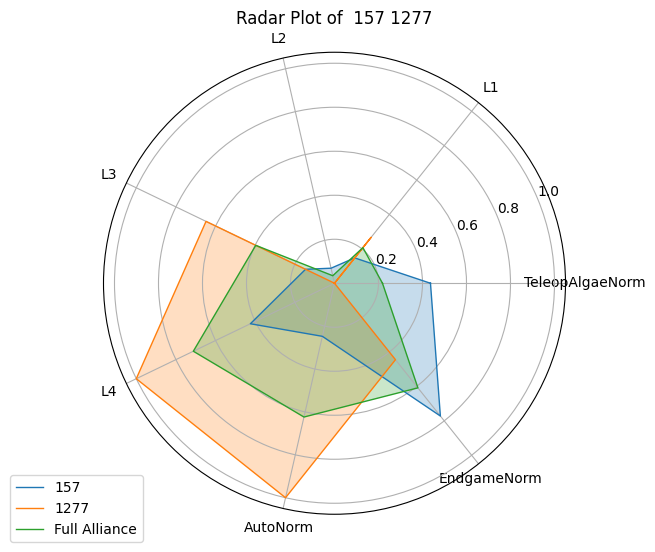

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


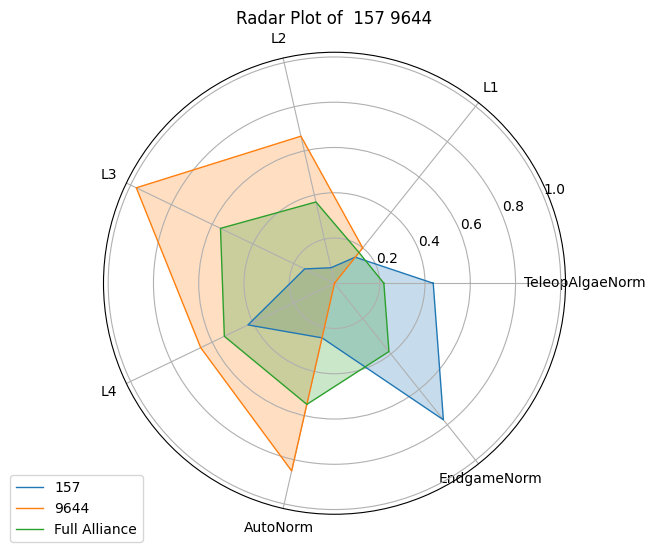

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


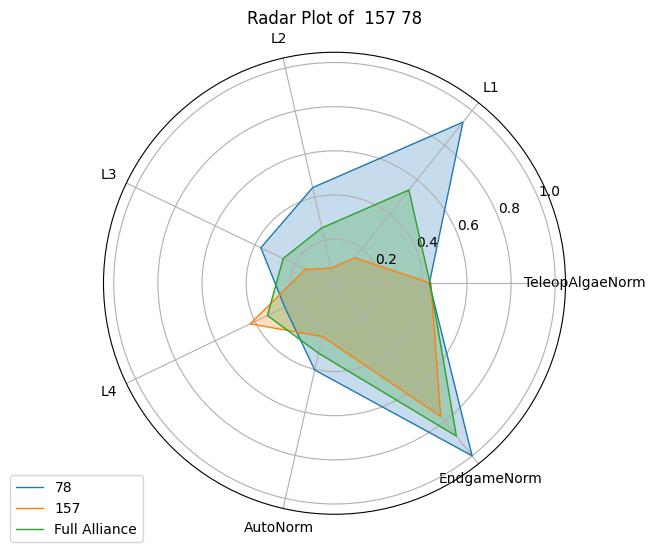

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


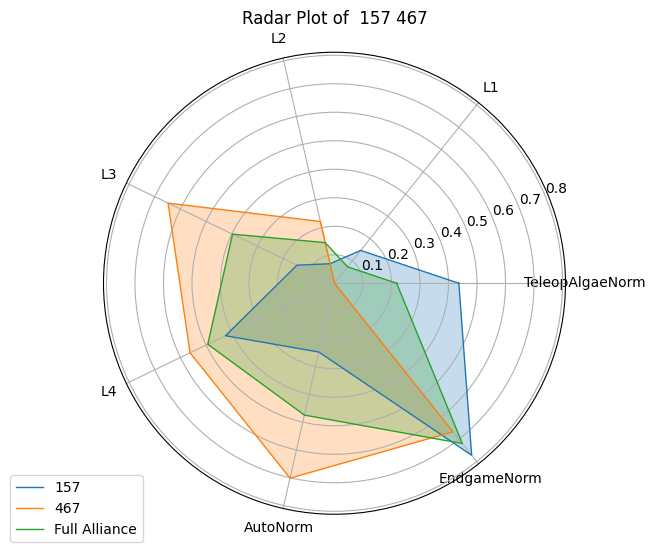

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


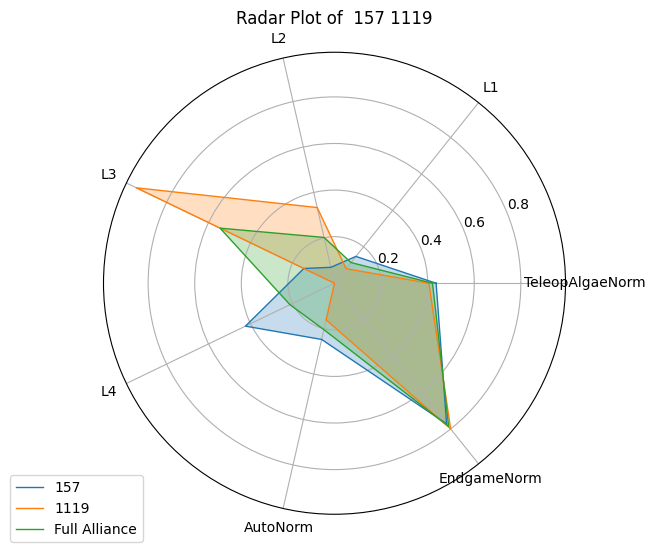

    Teams      Area
5    1277  0.545880
18   9644  0.511533
1      78  0.453118
3     467  0.440912
4    1119  0.366013
Alliance Drafting: 
[2423]
[69, 78, 88, 157, 190, 246, 467, 1119, 1153, 1277, 1757, 2079, 4048, 4909, 5000, 5459, 5735, 5962, 6201, 6731, 8544, 8567, 8626, 9101, 9443, 9644, 9991, 10063]
Our Top 5
Suggested Picks


/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


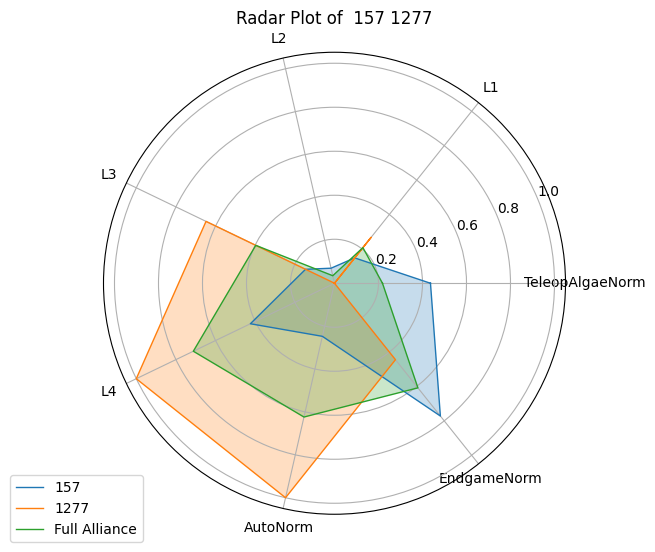

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


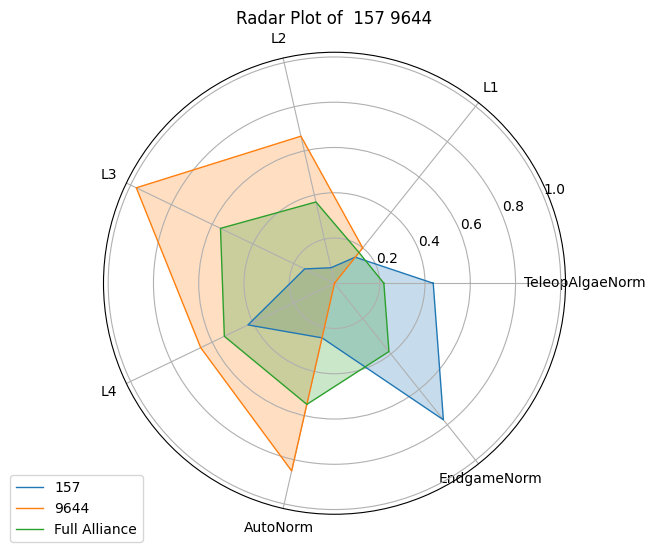

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


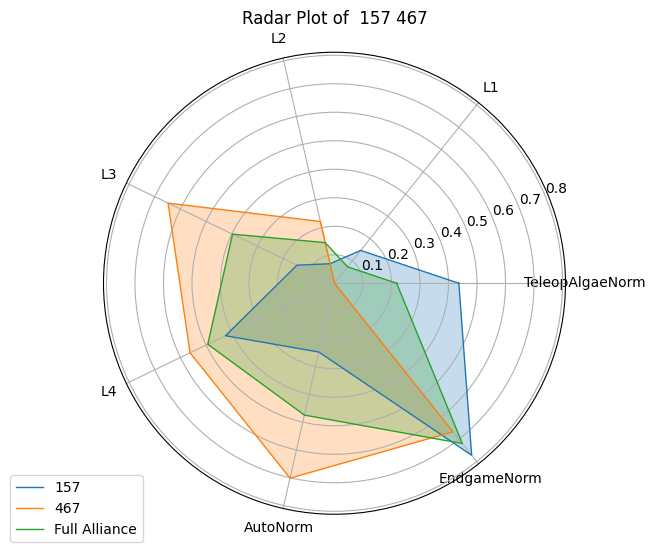

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


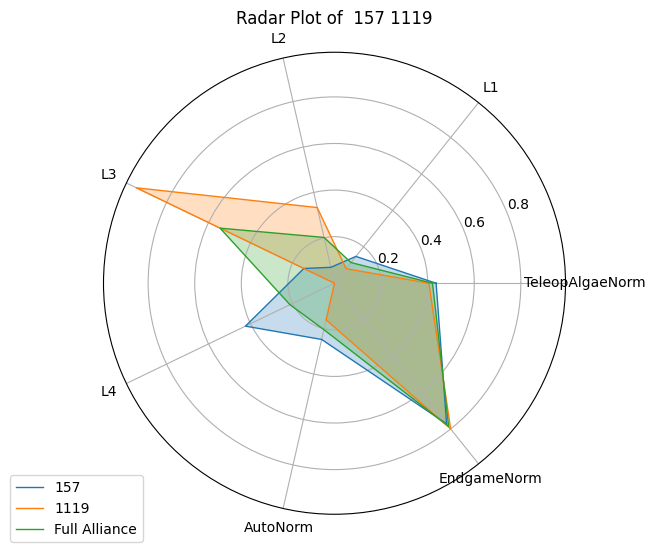

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


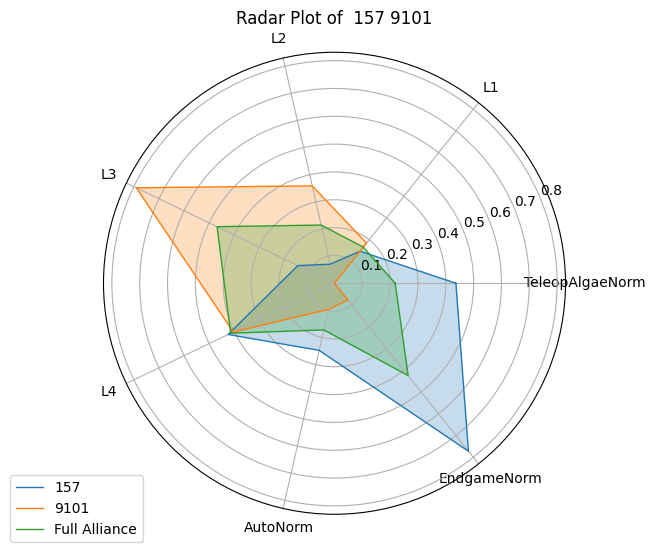

    Teams      Area
4    1277  0.545880
17   9644  0.511533
2     467  0.440912
3    1119  0.366013
15   9101  0.250299
Alliance Drafting: 
[190]
[69, 88, 157, 246, 467, 1119, 1153, 1277, 1757, 2079, 4048, 4909, 5000, 5459, 5735, 5962, 6201, 6731, 8544, 8567, 8626, 9101, 9443, 9644, 9991, 10063]
Our Top 5
Suggested Picks


/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


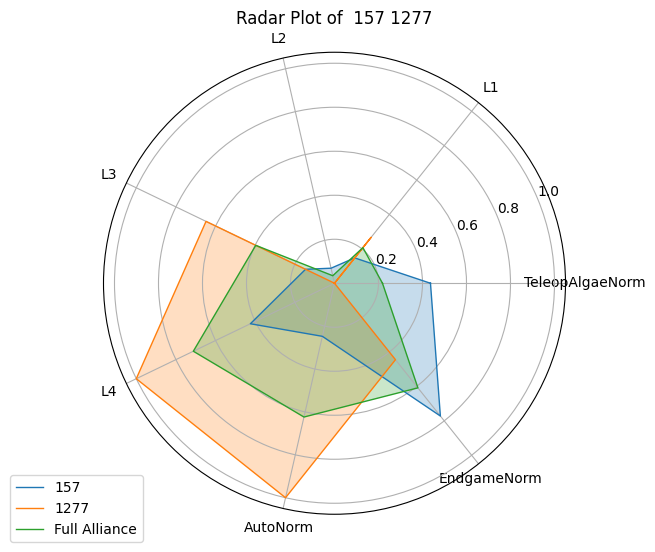

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


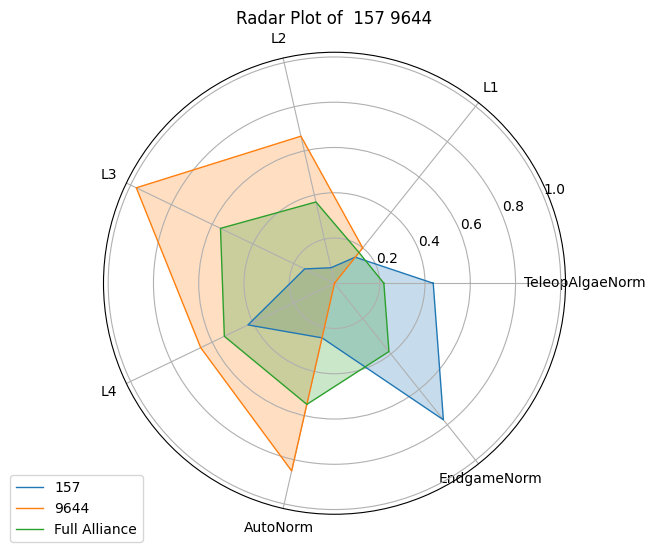

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


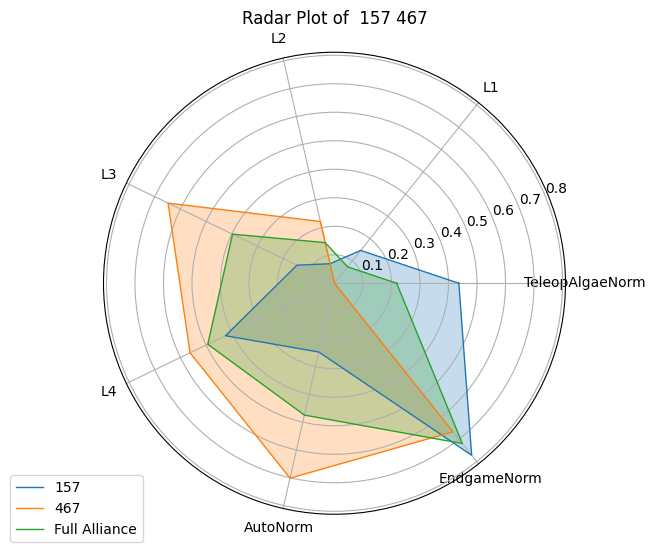

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


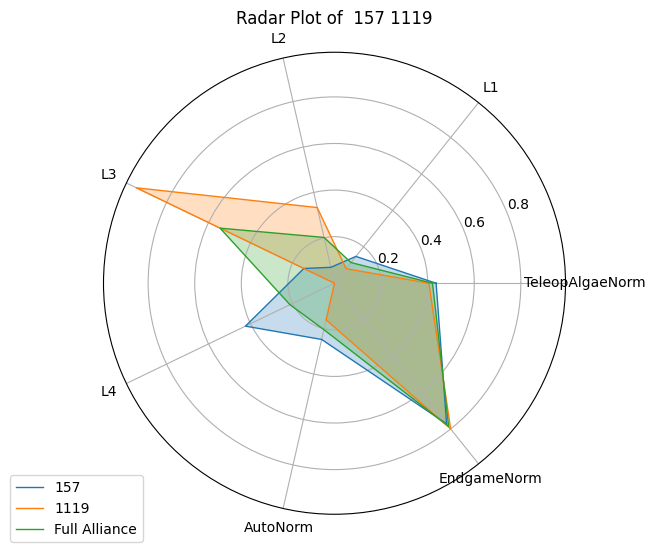

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


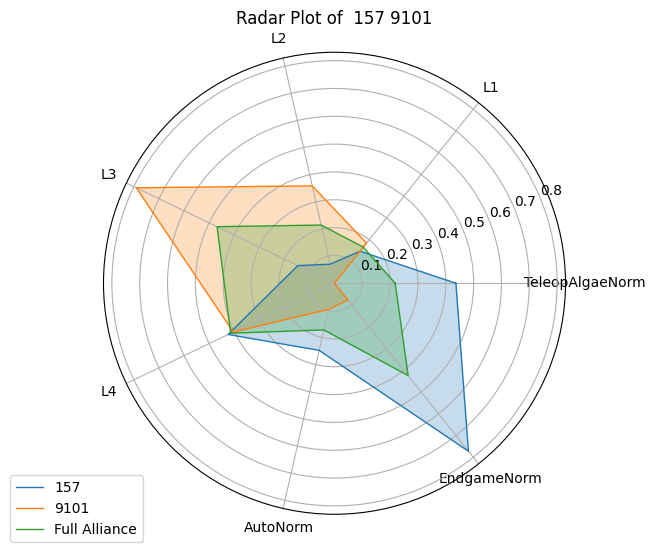

    Teams      Area
4    1277  0.545880
17   9644  0.511533
2     467  0.440912
3    1119  0.366013
15   9101  0.250299
Alliance Drafting: 
[1757]
[69, 157, 246, 467, 1119, 1153, 1277, 2079, 4048, 4909, 5000, 5459, 5735, 5962, 6201, 6731, 8544, 8567, 8626, 9101, 9443, 9644, 9991, 10063]
Our Top 5
Suggested Picks


/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


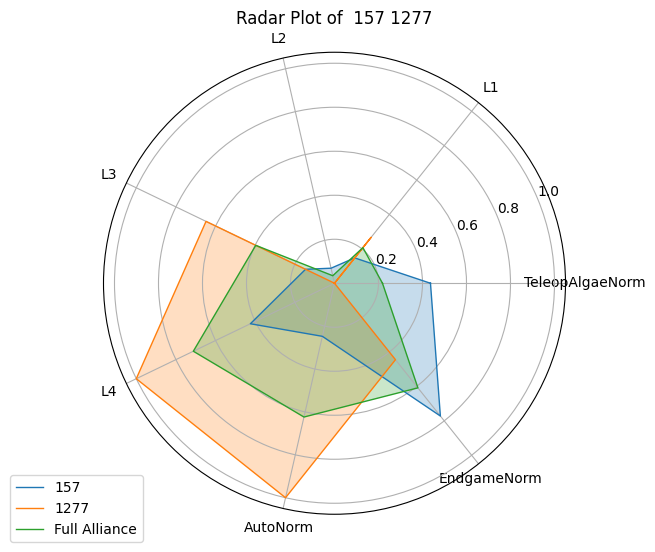

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


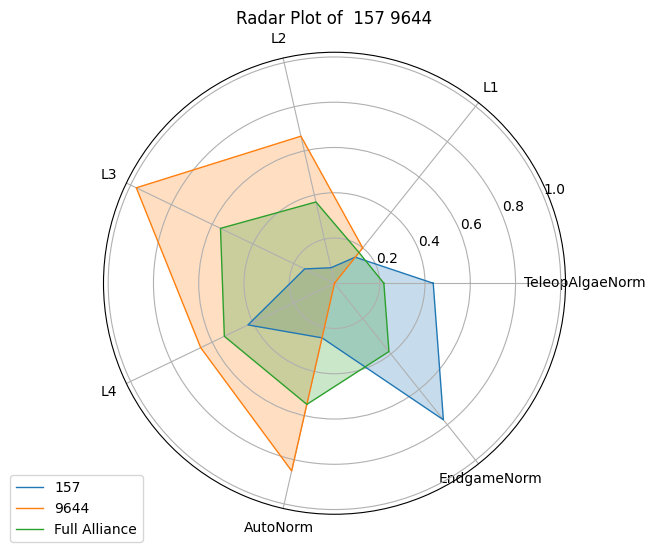

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


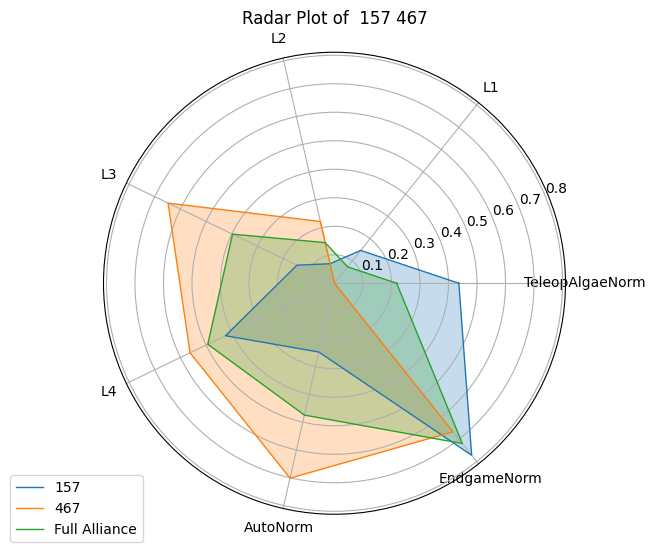

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


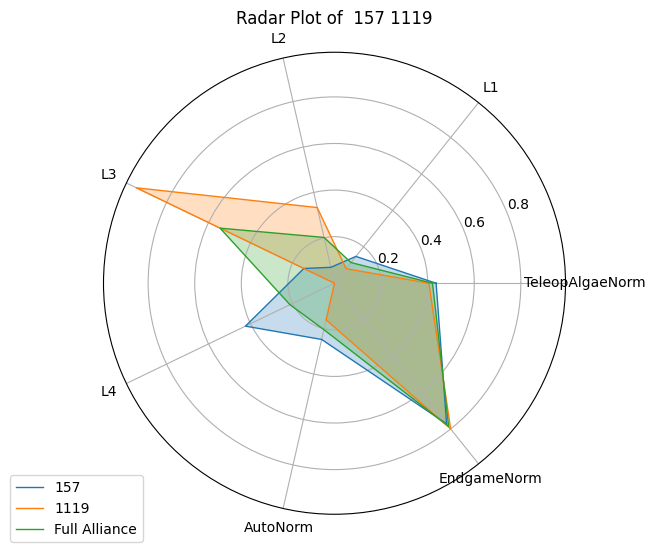

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


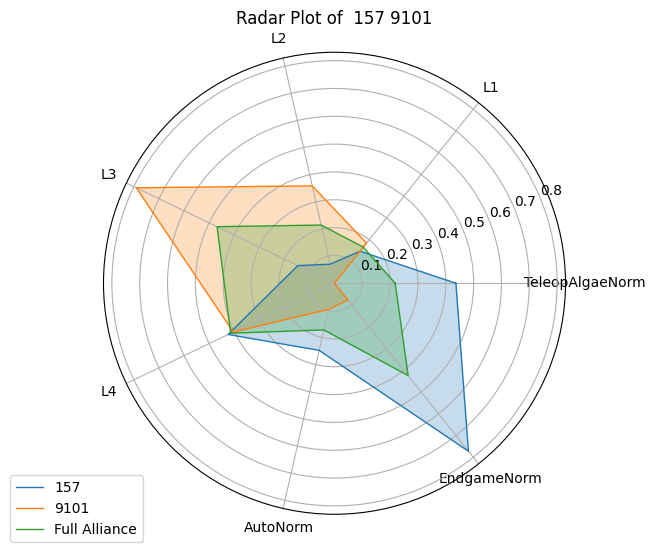

    Teams      Area
4    1277  0.545880
17   9644  0.511533
2     467  0.440912
3    1119  0.366013
15   9101  0.250299
Alliance Drafting: 
[9991]
[69, 157, 246, 467, 1119, 1277, 2079, 4048, 4909, 5000, 5459, 5735, 5962, 6201, 6731, 8544, 8567, 8626, 9101, 9443, 9644, 10063]
Our Top 5
Suggested Picks


/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


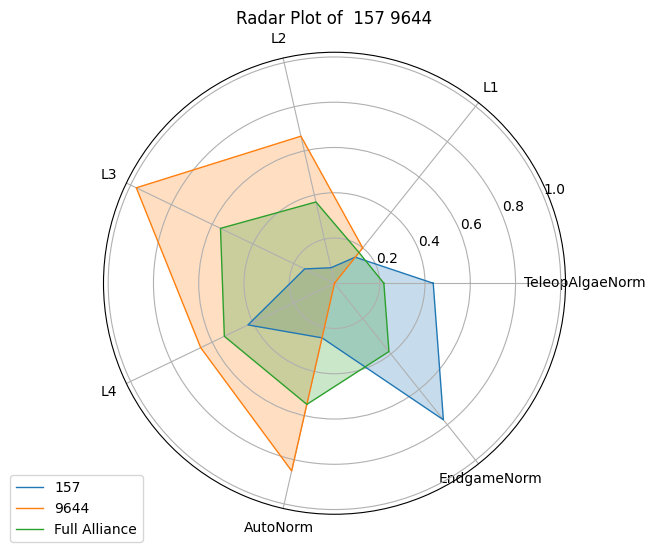

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


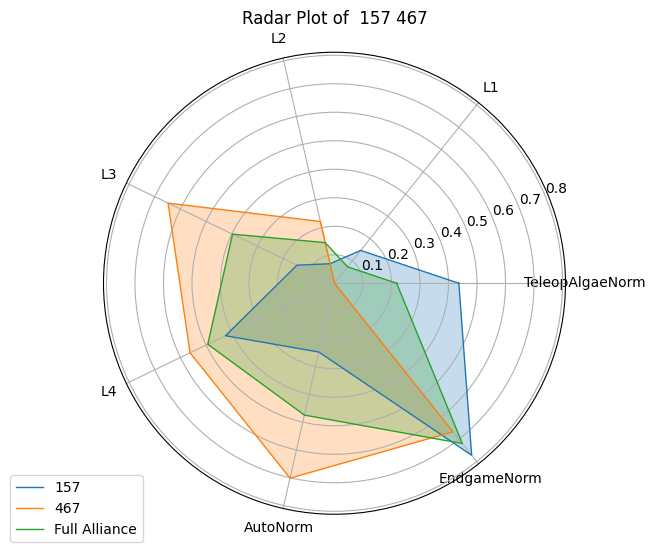

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


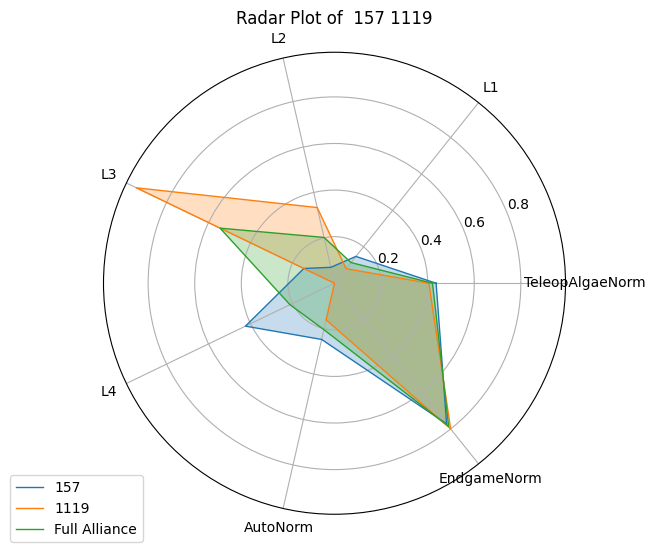

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


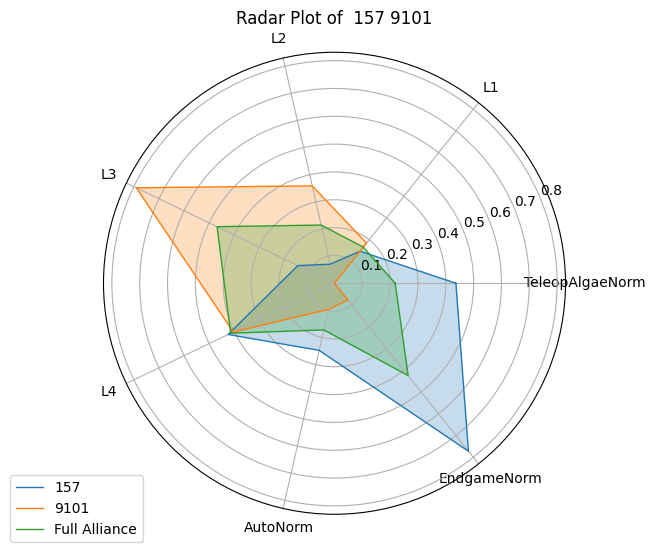

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


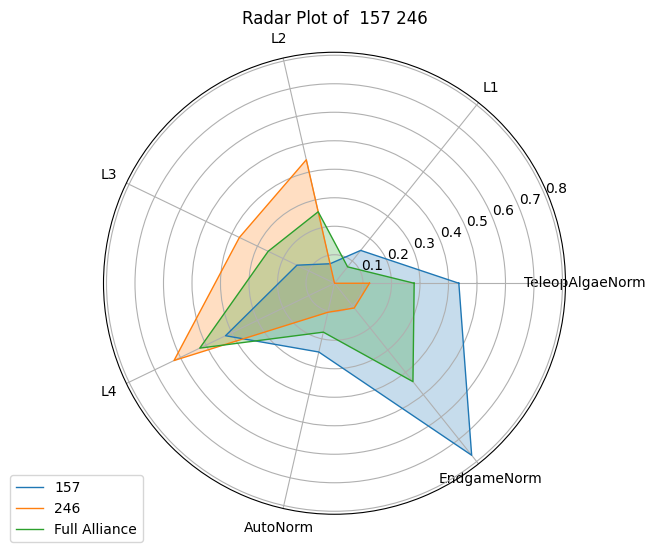

    Teams      Area
16   9644  0.511533
2     467  0.440912
3    1119  0.366013
14   9101  0.250299
1     246  0.245667
Alliance Drafting: 
[4909]
[69, 157, 246, 467, 1119, 2079, 4048, 5000, 5459, 5735, 5962, 6201, 6731, 8544, 8567, 8626, 9101, 9443, 9644, 10063]
Our Top 5
Suggested Picks


/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


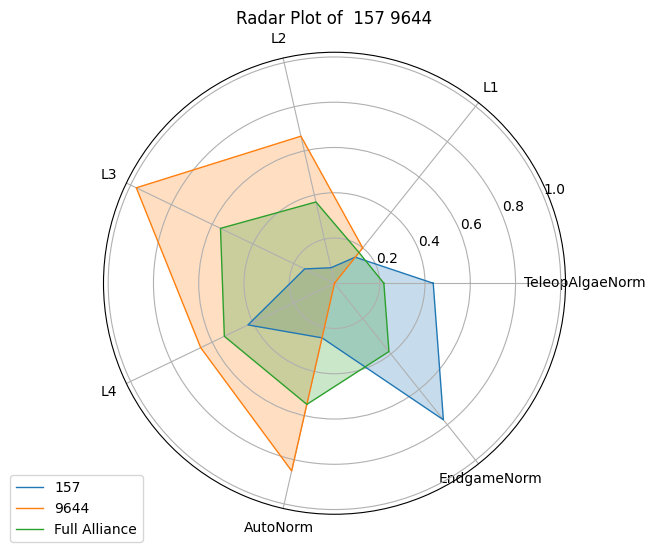

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


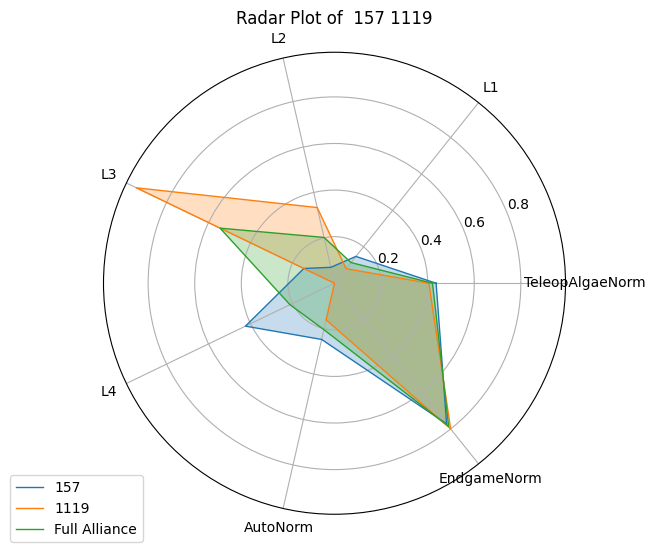

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


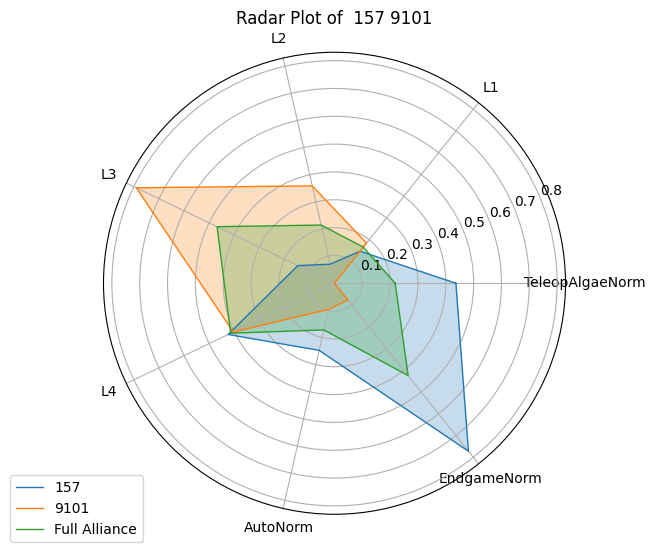

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


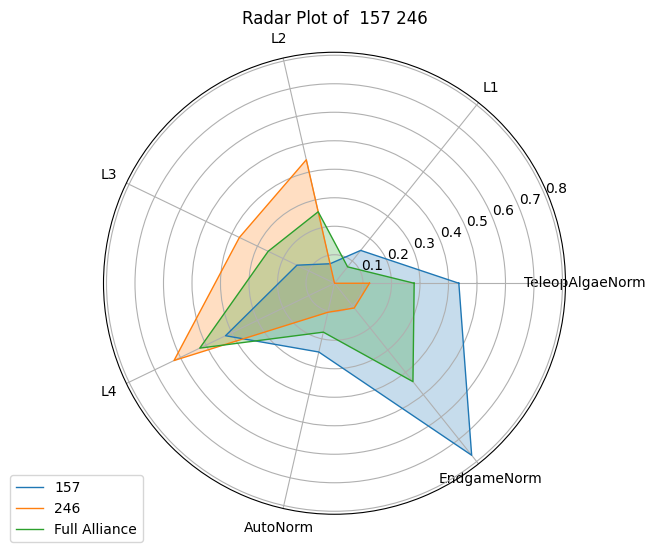

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


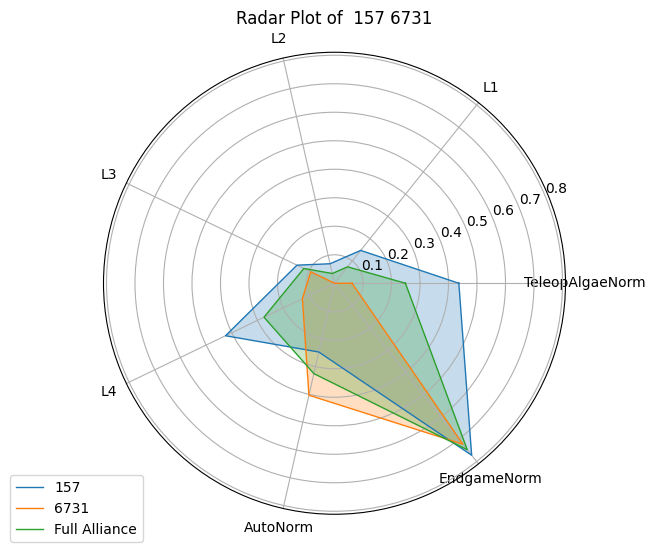

    Teams      Area
15   9644  0.511533
2    1119  0.366013
13   9101  0.250299
1     246  0.245667
9    6731  0.244180
Alliance Drafting: 
[5000]
[69, 157, 246, 1119, 2079, 4048, 5459, 5735, 5962, 6201, 6731, 8544, 8567, 8626, 9101, 9443, 9644, 10063]
My alliance Drafting: 
157
Suggested Picks


/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


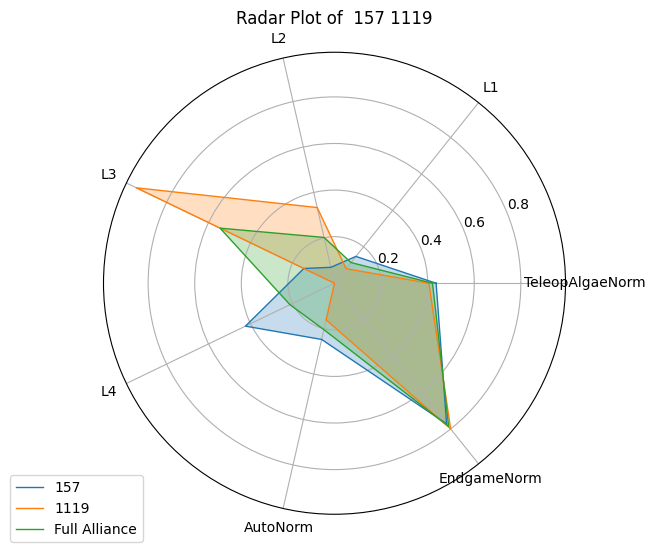

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


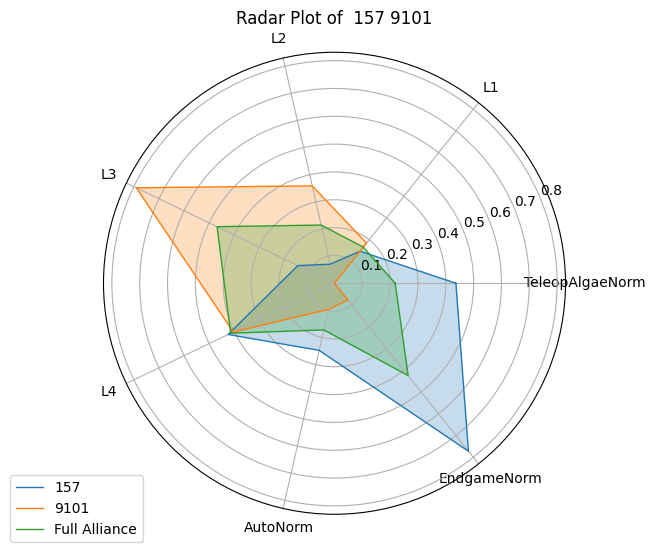

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


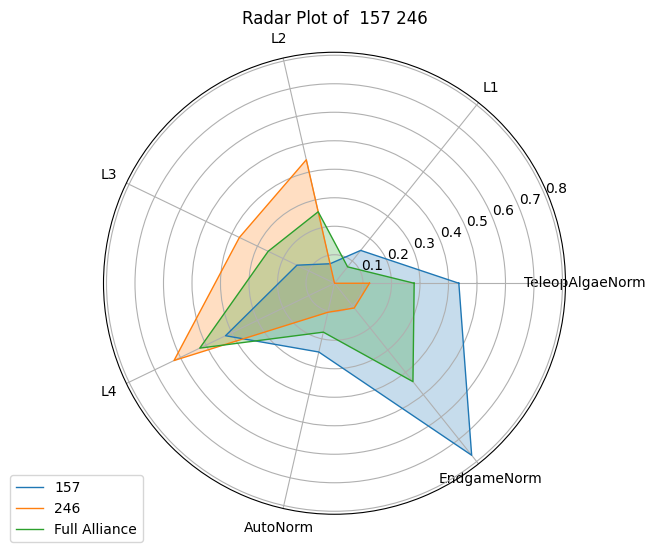

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


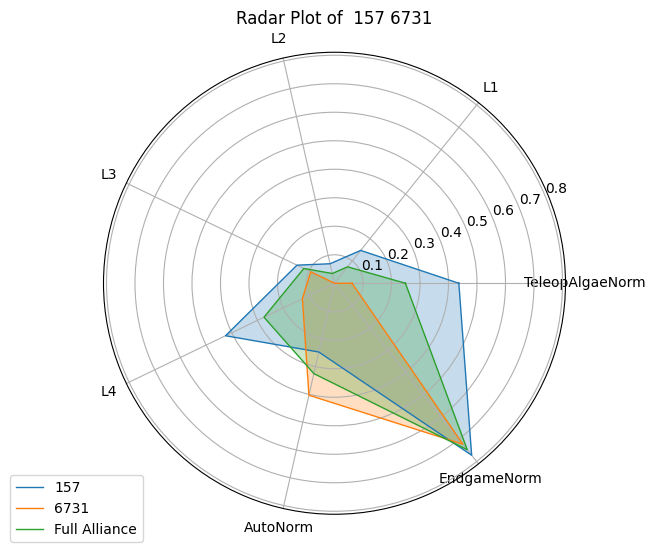

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


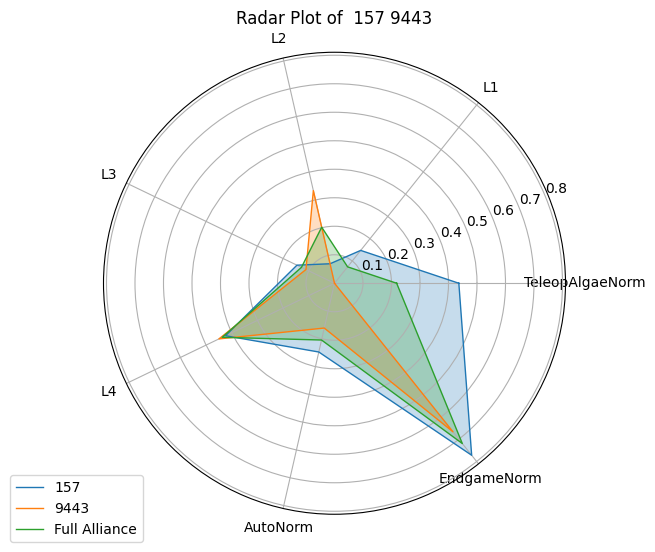

    Teams      Area
2    1119  0.366013
13   9101  0.250299
1     246  0.245667
9    6731  0.244180
14   9443  0.224913
9101
My alliance Drafting: 
[157, 9101]
Suggested Picks


/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


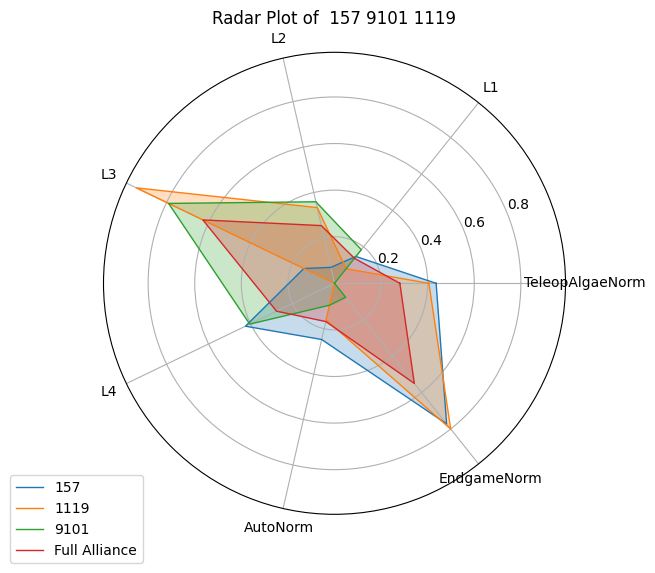

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


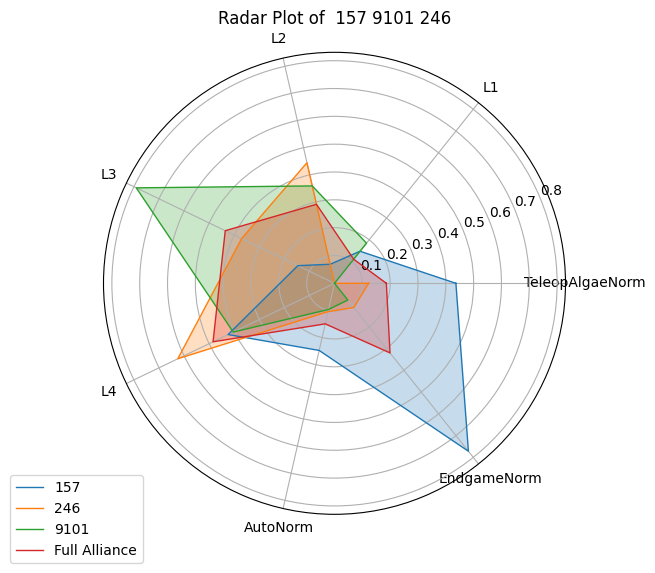

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


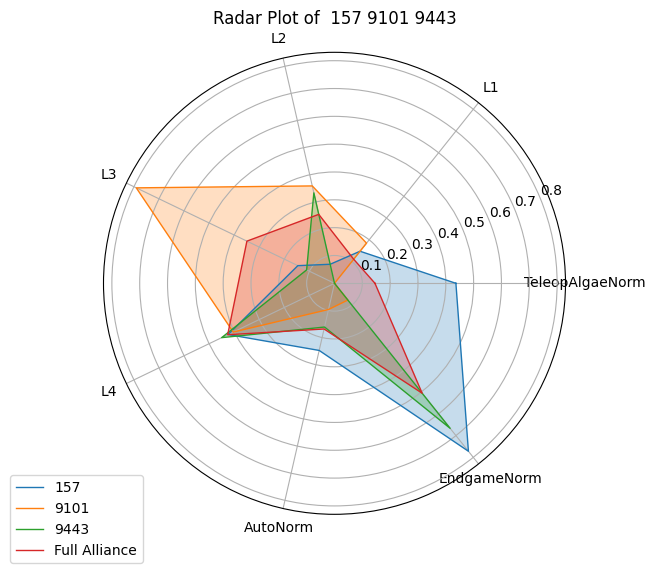

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


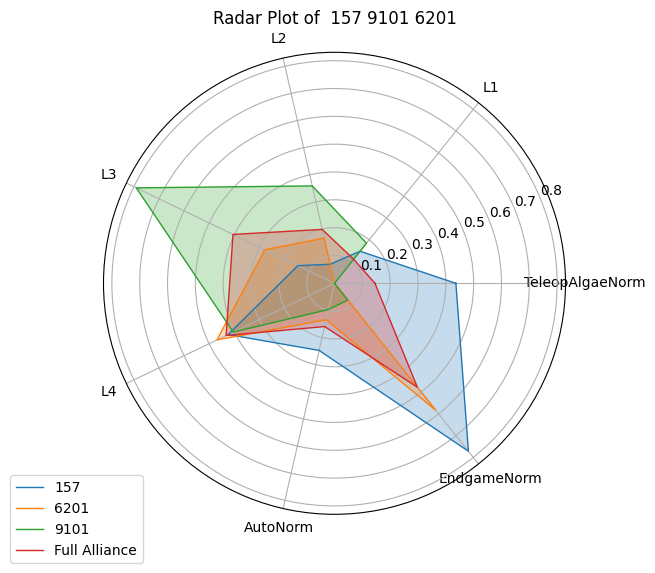

/tmp/ipykernel_3170/3511803546.py:10: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  alliance_data = alliance_data.append(total_teams, ignore_index=True)


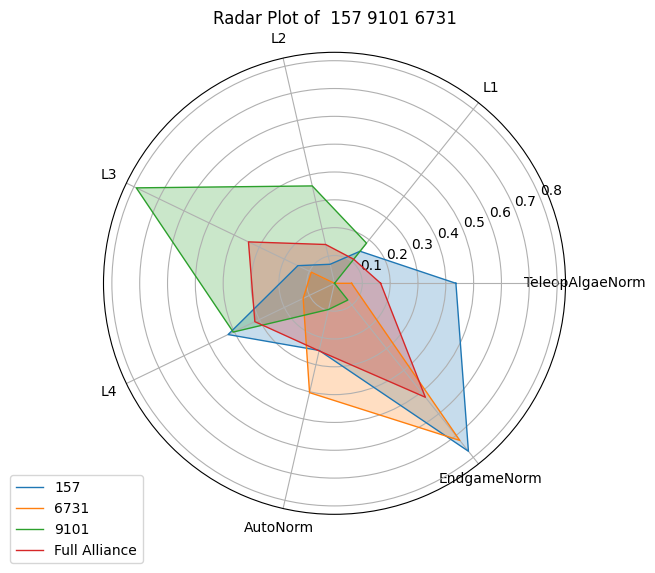

    Teams      Area
2    1119  0.301801
1     246  0.247712
13   9443  0.218592
8    6201  0.215967
9    6731  0.207065


ValueError: invalid literal for int() with base 10: ''

In [9]:
single_optimized_alliances = optimize(157, top_8, just_outside, comp, picking=True)

In [ ]:
show_alliance_radar([157, 1073, 9443], combined = True)

In [ ]:
alliances = optimize_all(157, top_8, just_outside, comp, picking=True)

In [27]:
alliances

NameError: name 'alliances' is not defined